In [1]:
import kagglehub

# Download latest version
dataset_path = kagglehub.dataset_download("hbchaitanyabharadwaj/audio-dataset-with-10-indian-languages")

dataset_path = dataset_path + "/Language Detection Dataset"
print("Path to dataset files:", dataset_path)

Path to dataset files: /kaggle/input/audio-dataset-with-10-indian-languages/Language Detection Dataset


## Task A

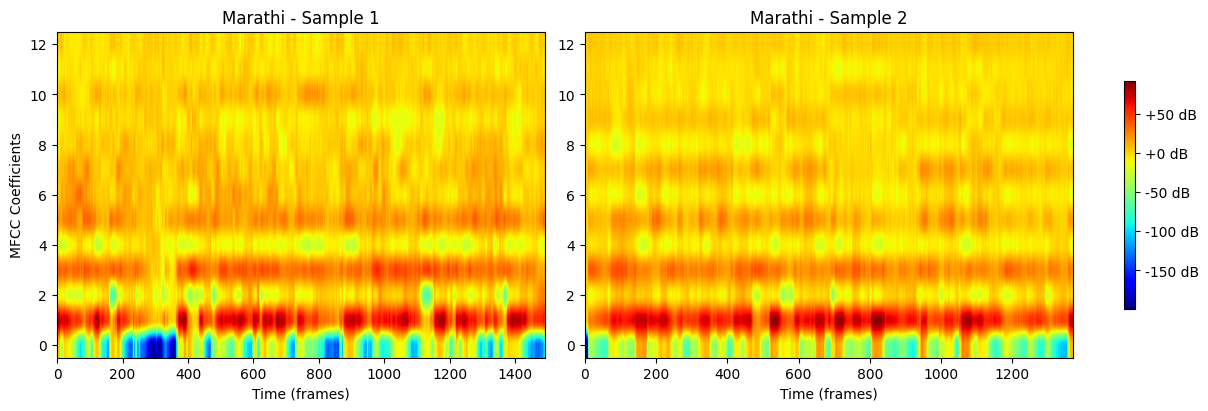

Marathi - Sample 1: MFCC Mean: [2.048464  0.8596929], Variance: [397253.12 248985.11]
Marathi - Sample 2: MFCC Mean: [3.7191103 3.727614 ], Variance: [95952.89 95561.84]


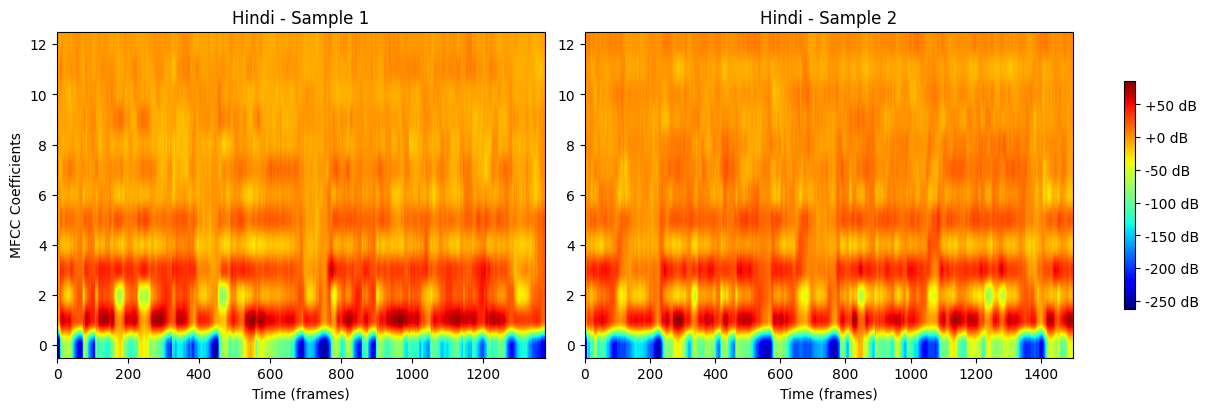

Hindi - Sample 1: MFCC Mean: [-2.5293324 -2.5301905], Variance: [495461.84 496723.  ]
Hindi - Sample 2: MFCC Mean: [-3.7225397 -3.7236917], Variance: [903842.3 906839.2]


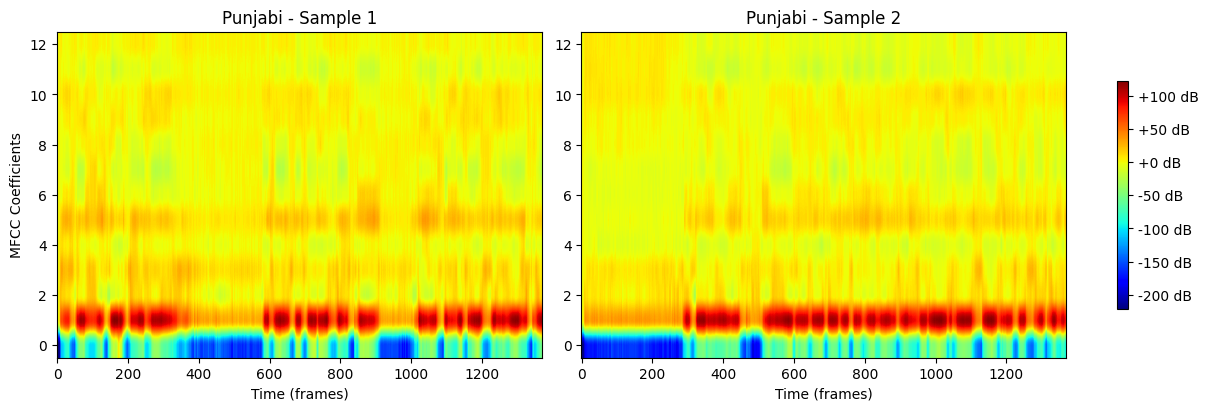

Punjabi - Sample 1: MFCC Mean: [-0.7639154 -0.7639872], Variance: [307642.12 307634.72]
Punjabi - Sample 2: MFCC Mean: [-0.9742848  -0.97230405], Variance: [415476.84 414066.47]


In [2]:
import os
import torch
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
import numpy as np

# Languages to analyze
languages = ['Marathi', 'Hindi', 'Punjabi']

# MFCC Transform
transform = T.MFCC(
    sample_rate=16000, 
    n_mfcc=13, 
    melkwargs={'n_fft': 400, 'hop_length': 160, 'n_mels': 23, 'center': False}
)

# Function to extract MFCC
def extract_mfcc(file_path):
    waveform, sample_rate = torchaudio.load(file_path)
    mfcc = transform(waveform)
    return mfcc

# Function to plot MFCCs for two samples side by side
def plot_mfcc_pair(mfcc1, mfcc2, language):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    
    img1 = axes[0].imshow(mfcc1[0].detach().numpy(), cmap='jet', aspect='auto', origin='lower')
    axes[0].set_title(f"{language.capitalize()} - Sample 1")
    axes[0].set_xlabel('Time (frames)')
    axes[0].set_ylabel('MFCC Coefficients')

    img2 = axes[1].imshow(mfcc2[0].detach().numpy(), cmap='jet', aspect='auto', origin='lower')
    axes[1].set_title(f"{language.capitalize()} - Sample 2")
    axes[1].set_xlabel('Time (frames)')

    # Add a single colorbar for both images
    fig.colorbar(img2, ax=axes, format="%+2.0f dB", location="right", shrink=0.7)

    plt.show()

# Extract and visualize MFCCs for two samples per language
for language in languages:
    language_folder = os.path.join(dataset_path, language)
    files = os.listdir(language_folder)

    if len(files) < 2:
        print(f"Not enough files for {language}. Skipping...")
        continue

    sample_1 = os.path.join(language_folder, files[5])
    sample_2 = os.path.join(language_folder, files[14])

    mfcc1 = extract_mfcc(sample_1)
    mfcc2 = extract_mfcc(sample_2)

    plot_mfcc_pair(mfcc1, mfcc2, language)

    # Compute and print mean and variance of MFCC coefficients
    mfcc_mean_1 = mfcc1.mean(dim=-1).mean(dim=-1).numpy()
    mfcc_variance_1 = mfcc1.var(dim=-1).var(dim=-1).numpy()
    
    mfcc_mean_2 = mfcc2.mean(dim=-1).mean(dim=-1).numpy()
    mfcc_variance_2 = mfcc2.var(dim=-1).var(dim=-1).numpy()

    print(f"{language.capitalize()} - Sample 1: MFCC Mean: {mfcc_mean_1}, Variance: {mfcc_variance_1}")
    print(f"{language.capitalize()} - Sample 2: MFCC Mean: {mfcc_mean_2}, Variance: {mfcc_variance_2}")


## Task B

In [49]:
import os
import torch
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader

class LanguageDataset(Dataset):
    def __init__(self, dataset_path, languages, sample_rate=16000, n_mfcc=40, fixed_length=100):
        """
        Custom Dataset for Language Classification using MFCC features.

        Args:
        - dataset_path (str): Path to the dataset folder.
        - languages (list): List of language names (subfolder names).
        - sample_rate (int): Sampling rate for audio processing.
        - n_mfcc (int): Number of MFCC features to extract.
        - fixed_length (int): Fixed number of time frames for MFCCs.
        """
        self.dataset_path = dataset_path
        self.languages = languages
        self.sample_rate = sample_rate
        self.n_mfcc = n_mfcc
        self.fixed_length = fixed_length
        self.data = []

        # MFCC transformation
        self.mfcc_transform = T.MFCC(
            sample_rate=self.sample_rate,
            n_mfcc=self.n_mfcc,
            melkwargs={"n_fft": 512, "hop_length": 160, "n_mels": 40, "center": False}
        )

        # Load data
        self._load_data()

    def _load_data(self):
        """
        Loads the audio files, extracts MFCC features, and assigns labels.
        """
        for label, language in enumerate(self.languages):
            language_folder = os.path.join(self.dataset_path, language)
            if not os.path.isdir(language_folder):
                continue  

            for file in os.listdir(language_folder):
                file_path = os.path.join(language_folder, file)
                if file_path.endswith('.mp3'):
                    self.data.append((file_path, label))

    def __len__(self):
        return len(self.data)

    def _pad_or_truncate(self, mfcc):
        """
        Ensures MFCCs have a fixed number of time frames.
        - If MFCC is shorter, pad with zeros.
        - If longer, truncate.
        """
        num_frames = mfcc.shape[1]

        if num_frames < self.fixed_length:
            pad = torch.zeros(self.n_mfcc, self.fixed_length - num_frames)
            mfcc = torch.cat((mfcc, pad), dim=1)
        elif num_frames > self.fixed_length:
            mfcc = mfcc[:, :self.fixed_length]  # Truncate

        return mfcc

    def __getitem__(self, idx):
        """
        Returns the fixed-size MFCC features and label for a given index.
        """
        file_path, label = self.data[idx]
        try:
            # Load audio file
            waveform, sample_rate = torchaudio.load(file_path)
            # waveform, sample_rate = torchaudio.load( "/kaggle/input/audio-dataset-with-10-indian-languages/Language Detection Dataset/Bengali/6149.mp3")
            
           
            # waveform, sample_rate = torchaudio.load("/kaggle/input/audio-dataset-with-10-indian-languages/Language Detection Dataset/Telugu/10027.mp3")
            # Check duration (in seconds)
            duration = waveform.shape[1] / sample_rate  # Total samples / Sample rate
            # if duration <= 1.0:  
            #     # print(f"Skipping {file_path}: Duration {duration:.2f}s is too short.")
            #     return None
            # Convert to mono if stereo
            if waveform.shape[0] > 1:  
                waveform = waveform.mean(dim=0, keepdim=True)  
        
            # Ensure correct sample rate
            if sample_rate != self.sample_rate:
                resampler = T.Resample(orig_freq=sample_rate, new_freq=self.sample_rate)
                waveform = resampler(waveform)
        
            # Extract MFCC (ensuring correct dimensions)
            mfcc = self.mfcc_transform(waveform)  # Shape: (1, n_mfcc, time_frames)
            mfcc = mfcc.squeeze(0)  # Shape: (n_mfcc, time_frames)
        
            mfcc = mfcc.mean(axis = 1)
        
            return mfcc, label
        except Exception as e:
            # print(f"Skipping file {file_path} due to error: {e}")
            return None  # Return None if an error occurs



In [57]:
import random
from torch.utils.data import Subset
from torch.utils.data import random_split
languages = [
    "Bengali",
    "Gujarati",
    "Hindi",
    "Kannada",
    "Malayalam",
    "Marathi",
    "Punjabi",
    "Tamil",
    "Telugu",
    "Urdu"
]


# Load dataset
full_dataset = LanguageDataset(dataset_path, languages)
# num_samples = int(0.005 * len(full_dataset))
# indices = random.sample(range(len(full_dataset)), num_samples)
# subset_dataset = Subset(full_dataset, indices)
# full_dataset = subset_dataset
# Split into train and test sets (80% train, 20% test)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])
# To handle small audio clips <1s
def collate_fn(batch):
    """Filters out None values from the batch to prevent DataLoader crashes."""
    batch = [sample for sample in batch if sample is not None]  # Remove None values

    if len(batch) == 0:  
        print("Called")
        return None  # Return None if the entire batch is empty

    mfccs, labels = zip(*batch)  # Unzip batch into MFCC features and labels
    mfccs = torch.stack(mfccs)   # Convert list to tensor
    labels = torch.tensor(labels)  # Convert labels to tensor

    return mfccs, labels  # Only return if valid data exists


# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn = collate_fn)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, drop_last=True, collate_fn = collate_fn)


In [44]:
sample_mfcc, sample_label = train_dataset[25000]
print("MFCC Shape: ",sample_mfcc.shape)
print("Label Shape: ",sample_label)
print("Train data size: ",(train_size))
print("Test data size: ",(test_size))

MFCC Shape:  torch.Size([40])
Label Shape:  0
Train data size:  205466
Test data size:  51367


In [45]:
import torch.nn as nn
import torch.nn.functional as F

class LanguageClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(LanguageClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)  # First hidden layer (64)
        self.fc2 = nn.Linear(hidden_size, 128)  # Second hidden layer (128)
        self.fc3 = nn.Linear(128, 256)  # Third hidden layer (256)
        self.fc4 = nn.Linear(256, num_classes)  # Output layer
        
        self.dropout = nn.Dropout(0.2)  # Dropout to prevent overfitting

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)  # Dropout after first layer
        x = F.relu(self.fc2(x))
        x = self.dropout(x)  # Dropout after second layer
        x = F.relu(self.fc3(x))
        x = self.fc4(x)  # No activation on the output (use CrossEntropyLoss)
        return x

# Initialize the model
input_size = 40  # MFCC feature size
hidden_size = 64
num_classes = len(languages)

model = LanguageClassifier(input_size, hidden_size, num_classes)


In [ ]:
import torch.optim as optim
from tqdm import tqdm

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

    for mfccs, labels in progress_bar:
        mfccs, labels = mfccs.to(device), labels.to(device)
        # Forward pass
        outputs = model(mfccs)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=total_loss / (progress_bar.n + 1))

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}")

# Running for one epoch only but number of iterations were more.

cuda


Epoch [1/1], Loss: 0.4283


In [48]:
torch.save(model.state_dict(), "final_model.pth")

Evaluating:  17%|█▋        | 557/3210 [02:06<09:37,  4.59it/s]

Skipping file /kaggle/input/audio-dataset-with-10-indian-languages/Language Detection Dataset/Urdu/5339.mp3 due to error: stft(torch.FloatTensor[1, 42], n_fft=512, hop_length=160, win_length=512, window=torch.FloatTensor{[512]}, normalized=0, onesided=1, return_complex=1) : expected 0 < n_fft < 42, but got n_fft=512


Evaluating:  41%|████      | 1321/3210 [05:21<08:20,  3.77it/s]

Skipping file /kaggle/input/audio-dataset-with-10-indian-languages/Language Detection Dataset/Marathi/10568.mp3 due to error: stft(torch.FloatTensor[1, 305], n_fft=512, hop_length=160, win_length=512, window=torch.FloatTensor{[512]}, normalized=0, onesided=1, return_complex=1) : expected 0 < n_fft < 305, but got n_fft=512


Evaluating:  83%|████████▎ | 2669/3210 [11:11<02:15,  4.00it/s]

Skipping file /kaggle/input/audio-dataset-with-10-indian-languages/Language Detection Dataset/Tamil/6716.mp3 due to error: stft(torch.FloatTensor[1, 494], n_fft=512, hop_length=160, win_length=512, window=torch.FloatTensor{[512]}, normalized=0, onesided=1, return_complex=1) : expected 0 < n_fft < 494, but got n_fft=512


Evaluating:  89%|████████▉ | 2865/3210 [12:03<01:30,  3.81it/s]

Skipping file /kaggle/input/audio-dataset-with-10-indian-languages/Language Detection Dataset/Gujarati/6932.mp3 due to error: stft(torch.FloatTensor[1, 262], n_fft=512, hop_length=160, win_length=512, window=torch.FloatTensor{[512]}, normalized=0, onesided=1, return_complex=1) : expected 0 < n_fft < 262, but got n_fft=512


Test Accuracy: 0.8670


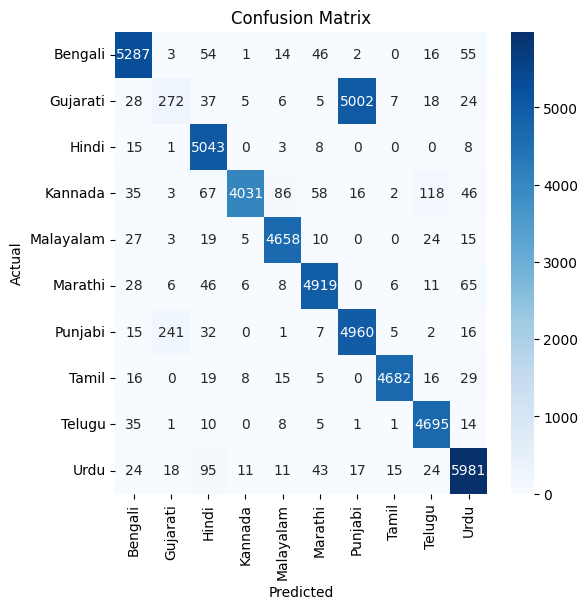

Classification Report:
              precision    recall  f1-score   support

     Bengali       0.96      0.97      0.96      5478
    Gujarati       0.50      0.05      0.09      5404
       Hindi       0.93      0.99      0.96      5078
     Kannada       0.99      0.90      0.95      4462
   Malayalam       0.97      0.98      0.97      4761
     Marathi       0.96      0.97      0.96      5095
     Punjabi       0.50      0.94      0.65      5279
       Tamil       0.99      0.98      0.98      4790
      Telugu       0.95      0.98      0.97      4770
        Urdu       0.96      0.96      0.96      6239

    accuracy                           0.87     51356
   macro avg       0.87      0.87      0.85     51356
weighted avg       0.87      0.87      0.84     51356



In [59]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

# Testing the model
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    progress_bar = tqdm(test_loader, desc="Evaluating", leave=False)

    for batch in progress_bar:
        try:
            mfccs, labels = batch  # Unpack batch
            mfccs, labels = mfccs.to(device), labels.to(device)
            
            outputs = model(mfccs)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        except Exception as e:
            # print(f"Skipping batch due to error: {e}")
            continue  

# Ensure there's valid data before computing metrics
if all_preds and all_labels:
    # Compute accuracy
    accuracy = accuracy_score(all_labels, all_preds)
    print(f"Test Accuracy: {accuracy:.4f}")

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Plot confusion matrix
    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=languages, yticklabels=languages)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    # Print classification report
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=languages))
else:
    print("No valid predictions were made. Check the dataset and model output.")


In [ ]:
# For details kindly refer to the report attached